# Analisi output embedding `simple_calendar`

Questo notebook replica l'analisi dell'output embedding fatta per `simple_spatial`, adattandola al caso `simple_calendar`.

`simple_calendar` e' un controllo negativo: i cluster differiscono solo per giorno assoluto della settimana, mentre il modello corrente non usa `timestamp` assoluto nelle feature di input. Per questo ci aspettiamo embedding poco separabili per cluster; una separazione forte sarebbe un indizio di leakage o di differenze non volute nei canali visibili (`importo`, `merchant`, `cocau`, `delta_t`).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 80)
pd.options.display.float_format = '{:.6f}'.format


mkdir -p failed for path /home/vscode/.config/matplotlib: [Errno 13] Permission denied: '/home/vscode/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-v2j8z69h because there was an issue with the default path (/home/vscode/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').is_dir() and (p / 'config.toml').exists():
            return p
    return start


ROOT = find_repo_root(Path.cwd())
EMB_PATH = ROOT / 'data' / 'output' / 'pred_simple_calendar_embeddings.csv'
PRED_PATH = ROOT / 'data' / 'transactions_simple_calendar_pred.csv'

missing = [p for p in [EMB_PATH, PRED_PATH] if not p.exists()]
if missing:
    raise FileNotFoundError(
        'Missing expected files. Run `uv run python run_experiment.py simple_calendar` first.\n'
        + '\n'.join(str(p) for p in missing)
    )

hemb = pd.read_csv(EMB_PATH)
df_pred = pd.read_csv(PRED_PATH)

CLIENT = 'client_id'
CLUSTER = 'cluster'
emb_cols = [c for c in hemb.columns if c.startswith('emb_')]
if not emb_cols:
    raise ValueError('No embedding columns found: expected columns named emb_0, emb_1, ...')

def cluster_phase(name: str) -> int:
    return int(str(name).rsplit('_', 1)[-1])


clusters = sorted(df_pred[CLUSTER].dropna().unique(), key=cluster_phase)
palette = ['tab:green', 'tab:blue', 'tab:orange', 'tab:red']
colors_map = dict(zip(clusters, palette))

print('Embedding file:', EMB_PATH)
print('Prediction input:', PRED_PATH)
print('Embedding rows x cols:', hemb.shape)
print('Prediction rows x cols:', df_pred.shape)
print('Embedding dimension:', len(emb_cols))


Embedding file: /workspaces/be-bper-ai-toolchain-bseq-app/data/output/pred_simple_calendar_embeddings.csv
Prediction input: /workspaces/be-bper-ai-toolchain-bseq-app/data/transactions_simple_calendar_pred.csv
Embedding rows x cols: (2975, 135)
Prediction rows x cols: (54465, 6)
Embedding dimension: 128


## 1. Join cluster label agli embedding

Il file embedding contiene finestre per cliente. Per una vista client-level prendiamo la finestra con `window_index` massimo per ogni `client_id`, come nel notebook `simple_spatial`, ma in modo esplicito e indipendente dall'ordine delle righe.


In [3]:
label_by_client = df_pred[[CLIENT, CLUSTER]].drop_duplicates()
ambiguous = label_by_client.groupby(CLIENT)[CLUSTER].nunique()
ambiguous = ambiguous[ambiguous > 1]
if not ambiguous.empty:
    raise ValueError(f'Clients with multiple clusters found: {ambiguous.index[:5].tolist()}')

label_by_client = label_by_client.drop_duplicates(CLIENT)

last_idx = hemb.groupby(CLIENT)['window_index'].idxmax()
hemb_last = hemb.loc[last_idx].reset_index(drop=True)
hemb_last = hemb_last.merge(label_by_client, on=CLIENT, how='left')

overview = pd.DataFrame({
    'n_embedding_windows': [len(hemb)],
    'n_embedding_clients': [hemb[CLIENT].nunique()],
    'n_client_level_rows': [len(hemb_last)],
    'embedding_dim': [len(emb_cols)],
    'missing_cluster_labels': [hemb_last[CLUSTER].isna().sum()],
})
display(overview)
display(hemb_last.head())


,n_embedding_windows,n_embedding_clients,n_client_level_rows,embedding_dim,missing_cluster_labels
0,2975,400,400,128,0


,client_id,client_code,window_index,window_start_ts,window_end_ts,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,...,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98,emb_99,emb_100,emb_101,emb_102,emb_103,emb_104,emb_105,emb_106,emb_107,emb_108,emb_109,emb_110,emb_111,emb_112,emb_113,emb_114,emb_115,emb_116,emb_117,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,window_start,window_end,cluster
0,0,0,7,1688757520,1703209438,-0.043700,-0.790049,0.336690,-0.639460,-0.232684,0.567773,-0.329301,0.615209,-1.773234,0.320292,1.356960,-1.684079,1.645703,-0.394767,1.162352,0.973314,0.094747,1.516270,-0.798371,0.859215,0.496247,-0.613614,0.922034,-1.416456,0.373436,1.175965,-0.334971,-1.248001,-0.180094,-0.835915,-0.982370,0.243989,-1.331906,-0.442080,1.122869,...,-0.179600,-0.611834,-0.124041,-1.189712,0.722317,0.452939,-0.142753,-0.305309,-0.023793,0.226160,1.249433,-1.451102,0.981529,0.436119,-0.258678,-0.685902,0.707507,1.144459,-0.470396,0.780753,-0.571314,-1.488991,0.900395,-0.827592,0.485975,0.133219,1.556533,0.600687,-1.175467,0.989403,0.737316,-0.094682,0.160916,0.274620,-0.434602,1.451158,0.441906,2023-07-07 19:18:40+00:00,2023-12-22 01:43:58+00:00,calendar_phase_2
1,1,1,7,1671573725,1686086627,-0.083358,-0.877117,1.056826,-0.265772,0.004467,0.838365,-0.639857,0.734017,-1.581868,0.319218,0.980490,-1.768162,1.457256,-0.690107,1.157161,0.856268,-0.260151,0.746529,-0.673885,0.782441,0.255952,-0.735988,1.204665,-1.529804,0.097618,1.323079,-0.228032,-1.304244,-0.370027,-0.505355,-1.556606,0.229343,-1.845334,-0.109410,0.891297,...,0.114648,-1.011100,-0.484533,-0.977497,0.760604,0.284123,0.674005,-0.401371,-0.038568,0.461118,0.912594,-1.554953,0.911410,0.636501,-0.469696,-0.718950,0.498028,1.245523,-0.539824,0.457854,-0.789159,-1.318032,0.808649,-0.931135,0.216561,0.337356,1.726920,0.469008,-0.777353,0.493257,0.977783,0.090596,0.530174,0.318636,-0.465146,0.849807,0.472312,2022-12-20 22:02:05+00:00,2023-06-06 21:23:47+00:00,calendar_phase_6
2,2,2,7,1634457003,1649024172,-0.110757,-0.863875,0.556272,-0.572302,-0.094057,0.555290,-0.443110,0.690975,-1.685302,0.371550,1.180582,-1.762783,1.629046,-0.480660,1.172310,0.925454,-0.005899,1.336691,-0.754347,0.864980,0.296492,-0.637359,1.003059,-1.518190,0.313376,1.187952,-0.417971,-1.177097,-0.230535,-0.743996,-1.112172,0.247248,-1.453146,-0.475834,1.115703,...,-0.130608,-0.654685,-0.121118,-1.212075,0.769483,0.296436,0.045102,-0.309949,-0.060744,0.243851,1.121494,-1.444269,0.893953,0.512512,-0.277892,-0.613633,0.640159,1.206532,-0.381460,0.836891,-0.630746,-1.422815,0.853036,-0.845601,0.415866,0.164645,1.616917,0.579031,-1.076766,0.954598,0.757465,-0.011541,0.279564,0.335440,-0.509316,1.400589,0.369617,2021-10-17 07:50:03+00:00,2022-04-03 22:16:12+00:00,calendar_phase_4
3,3,3,7,1668611954,1683155061,0.201633,-0.757465,0.972131,-0.390670,0.074913,0.819970,-0.479106,0.545045,-1.513044,0.226207,1.059597,-1.658964,1.201106,-0.635746,1.133043,0.662378,-0.046387,1.053912,-0.690884,0.458720,0.485950,-0.933750,1.206266,-1.391109,0.088757,1.549901,0.080678,-1.421837,-0.596991,-0.461888,-1.704982,0.281724,-2.113559,0.187619,0.409473,...,0.050342,-1.310558,-0.564729,-0.862340,0.561112,0.581196,0.841467,-0.261573,0.341099,0.530318,1.112785,-1.624205,1.122635,0.506636,-0.221477,-0.624954,0.617674,1.331104,-0.542241,0.376885,-0.953878,-1.523926,0.718380,-0.979864,0.189195,0.354049,1.865665,0.316608,-0.946560,0.422899,1.122949,0.193052,0.391010,-0.042157,-0.063960,0.598558,0.636152,2022-11-16 15:19:14+00:00,2023-05-03 23:04:21+00:00,calendar_phase_0
4,4,4,7,1686735271,1701284700,-0.039140,-0.910243,0.709415,-0.713627,0.221768,0.382959,-0.397836,0.817496,-1.540902,0.389359,0.931522,-1.737743,1.642558,-0.572185,1.195512,0.793361,0.064026,1.472650,-0.803041,0.854886,0.152502,-0.763290,1.04

,n_clients
cluster,
calendar_phase_0,100
calendar_phase_2,100
calendar_phase_4,100
calendar_phase_6,100


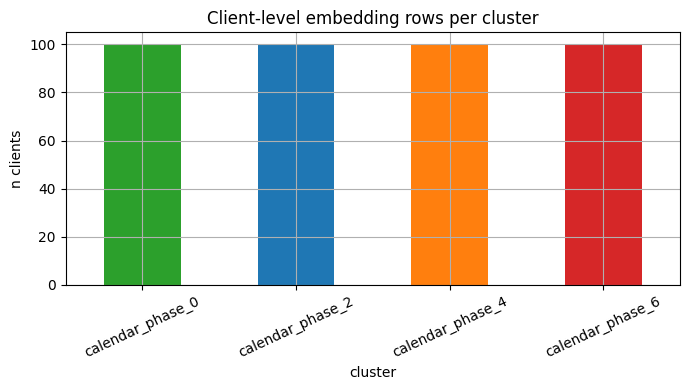

In [4]:
cluster_counts = hemb_last[CLUSTER].value_counts().reindex(clusters)
display(cluster_counts.to_frame('n_clients'))

fig, ax = plt.subplots(figsize=(7, 4))
cluster_counts.plot.bar(ax=ax, color=[colors_map[c] for c in clusters])
ax.set(title='Client-level embedding rows per cluster', xlabel='cluster', ylabel='n clients')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


## 2. PCA degli embedding client-level

Questa e' una visualizzazione non supervisionata. Se PC1/PC2 non separano i colori, non implica che non esista nessun segnale; implica solo che il segnale cluster non domina le prime due direzioni di varianza degli embedding.


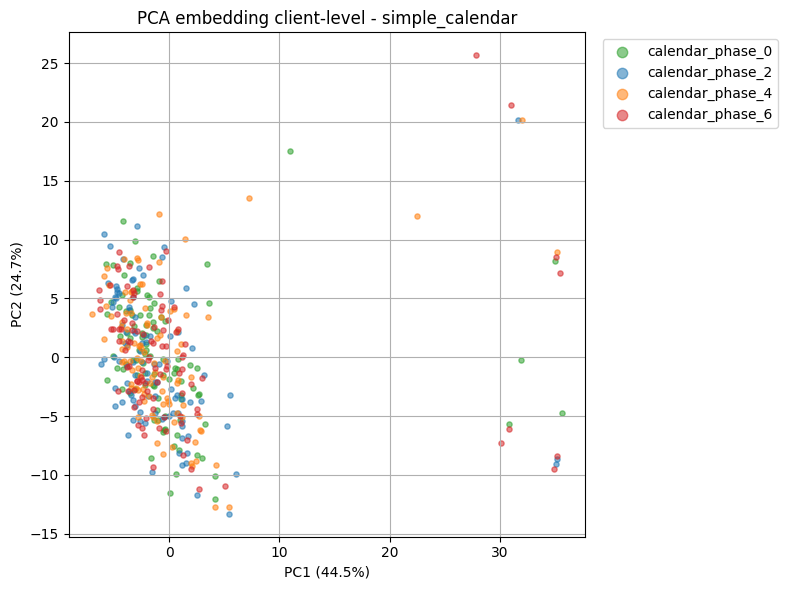

,component,explained_variance_ratio,cumulative
0,PC1,0.445366,0.445366
1,PC2,0.247426,0.692792


In [5]:
def pca_embedding_plot(frame: pd.DataFrame, title: str):
    plot_df = frame.dropna(subset=[CLUSTER]).copy()
    X = plot_df[emb_cols].to_numpy(dtype=float)
    X = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    Xp = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(8, 6))
    for c in clusters:
        mask = plot_df[CLUSTER].values == c
        ax.scatter(Xp[mask, 0], Xp[mask, 1], s=14, alpha=0.55, label=c, color=colors_map[c])

    ax.set(
        title=title,
        xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
        ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
    )
    ax.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    return plot_df, X, Xp, pca


plot_df, X_scaled, X_pca, pca = pca_embedding_plot(
    hemb_last,
    'PCA embedding client-level - simple_calendar',
)

pd.DataFrame({
    'component': ['PC1', 'PC2'],
    'explained_variance_ratio': pca.explained_variance_ratio_,
    'cumulative': np.cumsum(pca.explained_variance_ratio_),
})


## 3. Separazione quantitativa degli embedding

Per `simple_calendar` una regressione logistica sui soli embedding dovrebbe stare vicino al caso (`1 / n_cluster`, circa 25% con quattro cluster). Un valore alto indica che gli embedding contengono informazione di cluster non attesa per questo controllo negativo.


In [6]:
y = plot_df[CLUSTER].to_numpy()
chance_accuracy = 1.0 / len(np.unique(y))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42),
)
scores = cross_val_score(clf, plot_df[emb_cols], y, cv=cv)

centroids = pd.DataFrame(X_pca, columns=['PC1', 'PC2']).assign(cluster=y).groupby('cluster')[['PC1', 'PC2']].mean()
centroid_dist = pairwise_distances(centroids)
mean_centroid_dist = centroid_dist[np.triu_indices_from(centroid_dist, k=1)].mean()
within_rms = []
for c in clusters:
    pts = X_pca[y == c]
    within_rms.extend(np.linalg.norm(pts - centroids.loc[c].to_numpy(), axis=1))
within_rms = np.sqrt(np.mean(np.square(within_rms)))

diagnostics = pd.DataFrame([
    {
        'chance_accuracy': chance_accuracy,
        'logreg_cv_accuracy_mean': scores.mean(),
        'logreg_cv_accuracy_std': scores.std(),
        'pca2_mean_centroid_distance': mean_centroid_dist,
        'pca2_within_cluster_rms': within_rms,
        'pca2_centroid_to_within_ratio': mean_centroid_dist / within_rms if within_rms else np.nan,
    }
])
display(diagnostics)
display(pd.Series(scores, name='fold_accuracy').to_frame())


,chance_accuracy,logreg_cv_accuracy_mean,logreg_cv_accuracy_std,pca2_mean_centroid_distance,pca2_within_cluster_rms,pca2_centroid_to_within_ratio
0,0.250000,0.227500,0.031024,1.075344,9.390498,0.114514


,fold_accuracy
0,0.212500
1,0.275000
2,0.187500
3,0.212500
4,0.250000


## 4. PCA window-level

La vista window-level usa tutte le finestre predette, non solo l'ultima per cliente. Se il comportamento e' stabile, dovrebbe dare una lettura coerente con la vista client-level.


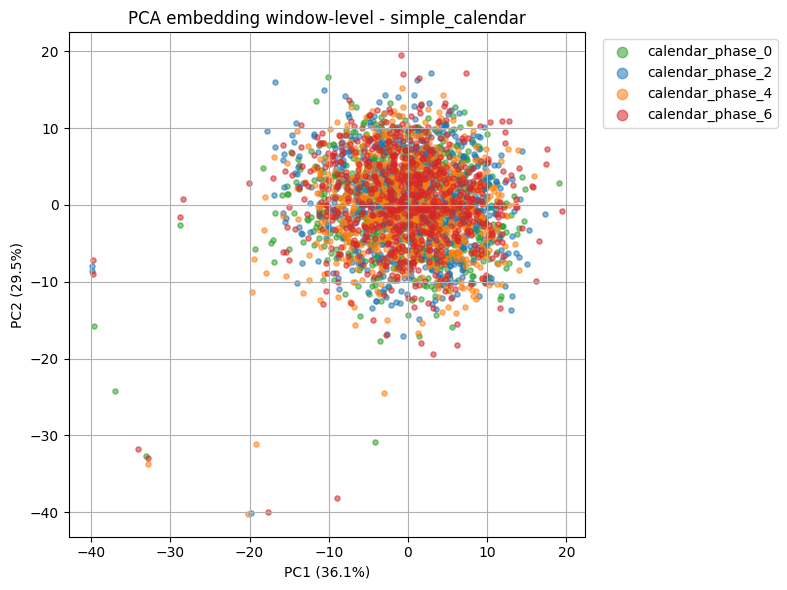

In [7]:
hemb_windows = hemb.merge(label_by_client, on=CLIENT, how='left')
_, _, _, _ = pca_embedding_plot(
    hemb_windows,
    'PCA embedding window-level - simple_calendar',
)
